# CN vs LMCI vs AD MRI Classification (`.nii` / `.nii.gz`)

该版本已从 CT/PNG 流程改为 MRI NIfTI 流程，并从二分类改为三分类：
- 递归读取三类目录中的 `.nii` 和 `.nii.gz`
- `CN` 目录标记为正常（label=0）
- `LMCI` 目录标记为轻度认知障碍中间阶段（label=1）
- `ADNI1` 目录标记为阿尔兹海默症（label=2）
- 不再进行文件重命名
- 使用 3D CNN 完成训练与评估


In [1]:
# 如果环境缺少依赖，请取消注释后执行：
# !pip install nibabel scipy scikit-learn tensorflow

import os
import random
import logging
from pathlib import Path
from datetime import datetime

os.environ["TF_ENABLE_XLA"] = "0"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/biolab_374/anaconda3/envs/dl-assignment --xla_gpu_enable_triton_gemm=false"

# 避免 XLA 触发 libdevice.10.bc 错误（需在 import tensorflow 前设置）
os.environ.setdefault('TF_XLA_FLAGS', '--tf_xla_auto_jit=0')
if 'XLA_FLAGS' not in os.environ and os.environ.get('CONDA_PREFIX'):
    os.environ['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={os.environ['CONDA_PREFIX']}"

import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_to_output
from scipy.ndimage import zoom
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_score

# 双保险：禁用 TF XLA JIT
tf.config.optimizer.set_jit(False)
print("TF_ENABLE_XLA =", os.environ.get("TF_ENABLE_XLA"))
print("TF_XLA_FLAGS  =", os.environ.get("TF_XLA_FLAGS"))
print("XLA_FLAGS     =", os.environ.get("XLA_FLAGS"))
tf.config.optimizer.set_jit(False)

# 可选：按需申请显存，降低 OOM 风险
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print('TensorFlow:', tf.__version__)
print('GPU devices:', gpus)
print('TF_XLA_FLAGS:', os.environ.get('TF_XLA_FLAGS'))
print('XLA_FLAGS:', os.environ.get('XLA_FLAGS'))


2026-04-22 17:09:26.023622: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-22 17:09:26.023656: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-22 17:09:26.024754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 17:09:26.030106: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 17:09:26.596246: W tensorflow/compiler/tf2

TF_ENABLE_XLA = 0
TF_XLA_FLAGS  = --tf_xla_auto_jit=0
XLA_FLAGS     = --xla_gpu_cuda_data_dir=/home/biolab_374/anaconda3/envs/dl-assignment --xla_gpu_enable_triton_gemm=false
TensorFlow: 2.15.0
GPU devices: []
TF_XLA_FLAGS: --tf_xla_auto_jit=0
XLA_FLAGS: --xla_gpu_cuda_data_dir=/home/biolab_374/anaconda3/envs/dl-assignment --xla_gpu_enable_triton_gemm=false


2026-04-22 17:09:27.314015: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-22 17:09:27.315203: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-22 17:09:27.373134: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required l

In [2]:
# ----------------------------
# Config
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 修改为你的真实路径
CN_DIR = Path('/home/biolab_374/Downloads/image_data/nii_gz/CN')
LMCI_DIR = Path('/home/biolab_374/Downloads/image_data/nii_gz/LMCI')
ADNI1_DIR = Path('/home/biolab_374/Downloads/image_data/nii_gz/AD')

CLASS_NAMES = ['CN', 'LMCI', 'AD']
CLASS_TO_LABEL = {'CN': 0, 'LMCI': 1, 'AD': 2}

TARGET_SHAPE = (160, 160, 160)   # preprocessed 3D volume shape (D, H, W)
VIEW_SHAPE = (128, 128)          # per-view 2D input shape (H, W)
VIEW_HALF_RANGE = 8               # total slices per view = 2 * VIEW_HALF_RANGE + 1
CROP_MARGIN = 8
RESAMPLE_SPACING = (1.0, 1.0, 1.0)
INTENSITY_PERCENTILES = (1, 99)
BATCH_SIZE = 8
# ==================== 2026-04-22 MOD START ====================
# 变更内容：取消更激进的正则方向，保留 AdamW 和 val_loss 监控；
# 将训练轮数调整为 30，降低 label smoothing，并保持较温和的 dropout 以尽量保护 precision。
EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.02
# ===================== 2026-04-22 MOD END =====================
CAPSULE_STEM_FILTERS = (32, 64)
PRIMARY_CAP_DIM = 8
PRIMARY_CAP_CHANNELS = 8
PRIMARY_CAP_KERNEL = 3
PRIMARY_CAP_STRIDES = 2
VIEW_CAPSULES = 8
VIEW_CAP_DIM = 12
ROUTINGS = 3
BRANCH_FEATURE_DIM = 64
SLICE_DROPOUT = 0.10
BRANCH_DROPOUT = 0.30
FUSION_UNITS = 128
FUSION_DROPOUT = 0.35
STEM_DROPOUT = 0.10
AD_PICK_NUM = 1000
LMCI_PICK_NUM = 800
CN_PICK_NUM = 1000

# 运行日志：以模型开始运行日期时间开头
RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
LOG_DIR = Path.cwd() / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / f'{RUN_TIMESTAMP}_data_loading.log'

logger = logging.getLogger('alz_mri_loader')
logger.setLevel(logging.INFO)
logger.handlers.clear()
file_handler = logging.FileHandler(LOG_FILE, encoding='utf-8')
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)
logger.propagate = False
logger.info('Run started.')
print('Log file:', LOG_FILE)

assert CN_DIR.exists(), f'CN_DIR not found: {CN_DIR}'
assert LMCI_DIR.exists(), f'LMCI_DIR not found: {LMCI_DIR}'
assert ADNI1_DIR.exists(), f'ADNI1_DIR not found: {ADNI1_DIR}'


Log file: /home/biolab_374/PycharmProjects/alz_image_classification/BIOCB26/logs/20260422_170927_data_loading.log


In [3]:
# ----------------------------
# Recursive scan of NIfTI files
# ----------------------------
def list_nifti_files(root: Path, num: int):
    # 同时支持未压缩和 gzip 压缩的 NIfTI 文件
    return random.sample(sorted(
        p for p in root.rglob('*')
        if p.is_file() and (p.name.endswith('.nii') or p.name.endswith('.nii.gz'))
    ), num)

cn_files = list_nifti_files(CN_DIR, CN_PICK_NUM)
lmci_files = list_nifti_files(LMCI_DIR, LMCI_PICK_NUM)
adni_files = list_nifti_files(ADNI1_DIR, AD_PICK_NUM)

print('CN files:', len(cn_files))
print('LMCI files:', len(lmci_files))
print('AD files:', len(adni_files))

records = []
for p in cn_files:
    records.append({'filepath': str(p), 'label': CLASS_TO_LABEL['CN'], 'group': 'CN'})
for p in lmci_files:
    records.append({'filepath': str(p), 'label': CLASS_TO_LABEL['LMCI'], 'group': 'LMCI'})
for p in adni_files:
    records.append({'filepath': str(p), 'label': CLASS_TO_LABEL['AD'], 'group': 'AD'})

df = pd.DataFrame(records)
print(df['group'].value_counts())
df.head()


CN files: 1000
LMCI files: 800
AD files: 1000
group
CN      1000
AD      1000
LMCI     800
Name: count, dtype: int64


,filepath,label,group
0,/home/biolab_374/Downloads/image_data/nii_gz/C...,0,CN
1,/home/biolab_374/Downloads/image_data/nii_gz/C...,0,CN
2,/home/biolab_374/Downloads/image_data/nii_gz/C...,0,CN
3,/home/biolab_374/Downloads/image_data/nii_gz/C...,0,CN
4,/home/biolab_374/Downloads/image_data/nii_gz/C...,0,CN


In [4]:
# ----------------------------
# Train/Val/Test split
# ----------------------------
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=SEED, stratify=train_df['label']
)

print('Train:', len(train_df), train_df['label'].value_counts().to_dict())
print('Val  :', len(val_df), val_df['label'].value_counts().to_dict())
print('Test :', len(test_df), test_df['label'].value_counts().to_dict())


Train: 1792 {2: 640, 0: 640, 1: 512}
Val  : 448 {2: 160, 0: 160, 1: 128}
Test : 560 {0: 200, 2: 200, 1: 160}


In [5]:
# ----------------------------
# NIfTI load + preprocess for 3-view 2D CNN
# - resample to 1x1x1 mm
# - non-zero bounding box crop + margin
# - resize volume to 160x160x160
# - extract configurable multi-slice stacks from three views
# ----------------------------
BAD_FILES = []
BAD_FILE_PATHS = set()
STACK_DEPTH = 2 * VIEW_HALF_RANGE + 1


def load_nifti_image(path: str) -> nib.Nifti1Image:
    img = nib.load(path)
    img = nib.as_closest_canonical(img)
    vol = img.get_fdata(dtype=np.float32)

    if vol.ndim == 4:
        vol = vol[..., 0]
    if vol.ndim != 3:
        raise ValueError(f'Unsupported volume shape: {vol.shape} @ {path}')

    return nib.Nifti1Image(vol, img.affine, img.header)


def resize_volume(volume: np.ndarray, target_shape=TARGET_SHAPE) -> np.ndarray:
    factors = [t / s for t, s in zip(target_shape, volume.shape)]
    return zoom(volume, factors, order=1).astype(np.float32)


def preprocess_volume(path: str, target_shape=TARGET_SHAPE) -> np.ndarray:
    img = load_nifti_image(path)
    img = resample_to_output(img, voxel_sizes=RESAMPLE_SPACING, order=1)
    vol = img.get_fdata(dtype=np.float32)

    mask = vol > 0
    if not np.any(mask):
        raise ValueError(f'Volume contains no non-zero voxels after resampling @ {path}')

    coords = np.argwhere(mask)
    mins = np.maximum(coords.min(axis=0) - CROP_MARGIN, 0)
    maxs = np.minimum(coords.max(axis=0) + 1 + CROP_MARGIN, vol.shape)
    vol = vol[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]]

    mask = vol > 0
    vox = vol[mask]
    lo, hi = np.percentile(vox, INTENSITY_PERCENTILES)
    vol = np.clip(vol, lo, hi)
    vol = (vol - lo) / (hi - lo + 1e-8)
    vol[~mask] = 0.0

    vol = resize_volume(vol, target_shape)
    return vol.astype(np.float32)


def get_slice_window(length: int, half_range: int = VIEW_HALF_RANGE):
    center = length // 2
    start = center - half_range
    stop = center + half_range + 1

    if start < 0:
        stop += -start
        start = 0
    if stop > length:
        start = max(0, start - (stop - length))
        stop = length

    indices = list(range(start, stop))
    while len(indices) < 2 * half_range + 1:
        if indices[0] > 0:
            indices.insert(0, indices[0] - 1)
        else:
            indices.append(indices[-1])

    return indices[: 2 * half_range + 1]


def resize_stack(stack: np.ndarray, target_hw=VIEW_SHAPE) -> np.ndarray:
    src_h, src_w, depth = stack.shape
    dst_h, dst_w = target_hw
    factors = (dst_h / src_h, dst_w / src_w, 1)
    return zoom(stack, factors, order=1).astype(np.float32)


def extract_view_stack(volume: np.ndarray, axis: int, half_range: int = VIEW_HALF_RANGE, target_hw=VIEW_SHAPE):
    indices = get_slice_window(volume.shape[axis], half_range)

    if axis == 0:
        stack = volume[indices, :, :]
        stack = np.moveaxis(stack, 0, -1)
    elif axis == 1:
        stack = volume[:, indices, :]
        stack = np.moveaxis(stack, 1, -1)
    else:
        stack = volume[:, :, indices]

    stack = resize_stack(stack, target_hw)
    return stack, indices


def volume_to_multiview_stacks(path: str):
    volume = preprocess_volume(path)
    axial_stack, axial_indices = extract_view_stack(volume, axis=0)
    coronal_stack, coronal_indices = extract_view_stack(volume, axis=1)
    sagittal_stack, sagittal_indices = extract_view_stack(volume, axis=2)
    metadata = {
        'axial_indices': axial_indices,
        'coronal_indices': coronal_indices,
        'sagittal_indices': sagittal_indices,
    }
    return volume, axial_stack, coronal_stack, sagittal_stack, metadata


def build_view_arrays(input_df, split_name: str):
    axial_views = []
    coronal_views = []
    sagittal_views = []
    labels = []
    kept_rows = []

    for row in input_df.itertuples(index=False):
        try:
            _, axial_stack, coronal_stack, sagittal_stack, _ = volume_to_multiview_stacks(row.filepath)
            axial_views.append(axial_stack)
            coronal_views.append(coronal_stack)
            sagittal_views.append(sagittal_stack)
            labels.append(int(row.label))
            kept_rows.append({'filepath': row.filepath, 'label': int(row.label), 'group': row.group})
        except Exception as e:
            if row.filepath not in BAD_FILE_PATHS:
                error_message = f'Failed preprocessing | split={split_name} | group={row.group} | label={row.label} | path={row.filepath} | error={e}'
                logger.error(error_message)
                BAD_FILES.append({'filepath': row.filepath, 'label': int(row.label), 'group': row.group, 'error': str(e)})
                BAD_FILE_PATHS.add(row.filepath)

    if not labels:
        raise RuntimeError(f'No valid samples available for split: {split_name}. Check log: {LOG_FILE}')

    arrays = {
        'axial': np.stack(axial_views).astype(np.float32),
        'coronal': np.stack(coronal_views).astype(np.float32),
        'sagittal': np.stack(sagittal_views).astype(np.float32),
    }
    labels_array = np.asarray(labels, dtype=np.int32)
    kept_df = pd.DataFrame(kept_rows)

    print(
        f"{split_name}: kept {len(labels_array)} samples | "
        f"axial={arrays['axial'].shape} coronal={arrays['coronal'].shape} sagittal={arrays['sagittal'].shape}"
    )
    return arrays, labels_array, kept_df


def to_model_inputs(arrays):
    return {
        'axial_input': arrays['axial'],
        'coronal_input': arrays['coronal'],
        'sagittal_input': arrays['sagittal'],
    }


train_arrays, y_train, train_kept_df = build_view_arrays(train_df, 'train')
val_arrays, y_val, val_kept_df = build_view_arrays(val_df, 'val')
test_arrays, y_test, test_kept_df = build_view_arrays(test_df, 'test')


train: kept 1786 samples | axial=(1786, 128, 128, 17) coronal=(1786, 128, 128, 17) sagittal=(1786, 128, 128, 17)
val: kept 448 samples | axial=(448, 128, 128, 17) coronal=(448, 128, 128, 17) sagittal=(448, 128, 128, 17)
test: kept 560 samples | axial=(560, 128, 128, 17) coronal=(560, 128, 128, 17) sagittal=(560, 128, 128, 17)


Processed volume shape: (160, 160, 160)
Axial stack indices   : [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]
Coronal stack indices : [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]
Sagittal stack indices: [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]


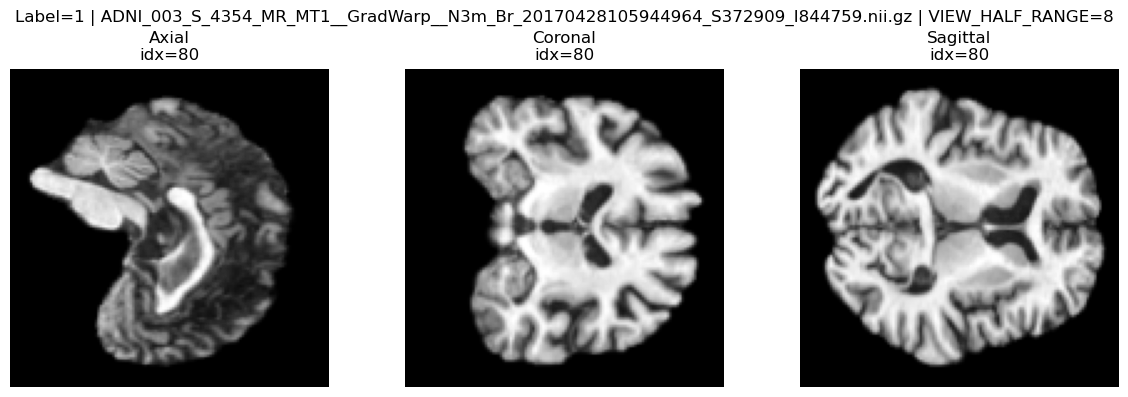

In [6]:
# ----------------------------
# 可视化样本（根据切片选择展示 3 路多切片输入）
# ----------------------------
sample_row = None
sample_volume = None
sample_axial = None
sample_coronal = None
sample_sagittal = None
sample_meta = None

for row in train_kept_df.itertuples(index=False):
    try:
        sample_volume, sample_axial, sample_coronal, sample_sagittal, sample_meta = volume_to_multiview_stacks(row.filepath)
        sample_label = int(row.label)
        sample_path = row.filepath
        sample_row = row
        break
    except Exception as e:
        logger.error(f'Visualization sample failed | path={row.filepath} | error={e}')

if sample_volume is None:
    raise RuntimeError(f'No valid training sample could be visualized. Check log: {LOG_FILE}')

center_idx = VIEW_HALF_RANGE
print('Processed volume shape:', sample_volume.shape)
print('Axial stack indices   :', sample_meta['axial_indices'])
print('Coronal stack indices :', sample_meta['coronal_indices'])
print('Sagittal stack indices:', sample_meta['sagittal_indices'])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_axial[:, :, center_idx], cmap='gray')
axes[0].set_title(f"Axial\nidx={sample_meta['axial_indices'][center_idx]}")
axes[1].imshow(sample_coronal[:, :, center_idx], cmap='gray')
axes[1].set_title(f"Coronal\nidx={sample_meta['coronal_indices'][center_idx]}")
axes[2].imshow(sample_sagittal[:, :, center_idx], cmap='gray')
axes[2].set_title(f"Sagittal\nidx={sample_meta['sagittal_indices'][center_idx]}")

for ax in axes:
    ax.axis('off')

plt.suptitle(f'Label={int(sample_label)} | {Path(sample_path).name} | VIEW_HALF_RANGE={VIEW_HALF_RANGE}')
plt.tight_layout()
plt.show()


In [7]:
# ----------------------------
# 3-view multi-slice CapsuleNet model
# ----------------------------
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
    scale = s_squared_norm / (1.0 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + keras.backend.epsilon())


class Length(keras.layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + keras.backend.epsilon())

    def compute_output_shape(self, input_shape):
        return input_shape[:-1]

    def get_config(self):
        return super().get_config()


class CapsuleLayer(keras.layers.Layer):
    def __init__(self, num_capsule, dim_capsule, routings=3, kernel_initializer='glorot_uniform', **kwargs):
        super().__init__(**kwargs)
        self.num_capsule = num_capsule
        self.dim_capsule = dim_capsule
        self.routings = routings
        self.kernel_initializer = keras.initializers.get(kernel_initializer)

    def build(self, input_shape):
        self.input_num_capsule = input_shape[1]
        self.input_dim_capsule = input_shape[2]
        self.W = self.add_weight(
            shape=(self.num_capsule, self.input_num_capsule, self.dim_capsule, self.input_dim_capsule),
            initializer=self.kernel_initializer,
            name='W'
        )
        super().build(input_shape)

    def call(self, inputs):
        inputs_hat = tf.einsum('bid,jiod->bjio', inputs, self.W)
        batch_size = tf.shape(inputs)[0]
        b = tf.zeros(shape=(batch_size, self.num_capsule, self.input_num_capsule), dtype=inputs.dtype)

        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=1)
            outputs = squash(tf.einsum('bji,bjio->bjo', c, inputs_hat))
            if i < self.routings - 1:
                b += tf.einsum('bjo,bjio->bji', outputs, inputs_hat)

        return outputs

    def compute_output_shape(self, input_shape):
        return (None, self.num_capsule, self.dim_capsule)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_capsule': self.num_capsule,
            'dim_capsule': self.dim_capsule,
            'routings': self.routings,
            'kernel_initializer': keras.initializers.serialize(self.kernel_initializer),
        })
        return config


def PrimaryCap(inputs, dim_capsule, n_channels, kernel_size, strides, padding, name_prefix):
    output = keras.layers.Conv2D(
        filters=dim_capsule * n_channels,
        kernel_size=kernel_size,
        strides=strides,
        padding=padding,
        activation='relu',
        name=f'{name_prefix}_primarycap_conv'
    )(inputs)
    outputs = keras.layers.Reshape(target_shape=(-1, dim_capsule), name=f'{name_prefix}_primarycap_reshape')(output)
    return keras.layers.Lambda(squash, name=f'{name_prefix}_primarycap_squash')(outputs)


def sparse_categorical_crossentropy_with_label_smoothing(num_classes, label_smoothing):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true = tf.one_hot(y_true, depth=num_classes)
        return keras.losses.categorical_crossentropy(
            y_true,
            y_pred,
            label_smoothing=label_smoothing,
        )
    return loss_fn


class MacroPrecisionCallback(keras.callbacks.Callback):
    def __init__(self, validation_inputs, validation_labels, batch_size=32):
        super().__init__()
        self.validation_inputs = validation_inputs
        self.validation_labels = validation_labels
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_prob = self.model.predict(self.validation_inputs, batch_size=self.batch_size, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        macro_precision = precision_score(
            self.validation_labels,
            y_pred,
            average='macro',
            zero_division=0,
        )
        logs['val_macro_precision'] = float(macro_precision)
        print(f" - val_macro_precision: {macro_precision:.4f}", end='')


def build_shared_capsule_encoder(input_shape=VIEW_SHAPE + (STACK_DEPTH,)):
    inputs = keras.layers.Input(shape=input_shape, name='view_input')
    x = keras.layers.SpatialDropout2D(SLICE_DROPOUT, name='slice_dropout')(inputs)
    x = keras.layers.Conv2D(
        CAPSULE_STEM_FILTERS[0],
        kernel_size=5,
        strides=2,
        padding='same',
        activation='relu',
        name='stem_conv1'
    )(inputs)
    x = keras.layers.BatchNormalization(name='stem_bn1')(x)
    x = keras.layers.Conv2D(
        CAPSULE_STEM_FILTERS[1],
        kernel_size=3,
        strides=2,
        padding='same',
        activation='relu',
        name='stem_conv2'
    )(x)
    x = keras.layers.BatchNormalization(name='stem_bn2')(x)
    x = keras.layers.MaxPool2D(pool_size=2, name='stem_pool')(x)
    x = keras.layers.SpatialDropout2D(STEM_DROPOUT, name='stem_dropout')(x)

    primary_caps = PrimaryCap(
        x,
        dim_capsule=PRIMARY_CAP_DIM,
        n_channels=PRIMARY_CAP_CHANNELS,
        kernel_size=PRIMARY_CAP_KERNEL,
        strides=PRIMARY_CAP_STRIDES,
        padding='valid',
        name_prefix='shared'
    )
    view_caps = CapsuleLayer(
        num_capsule=VIEW_CAPSULES,
        dim_capsule=VIEW_CAP_DIM,
        routings=ROUTINGS,
        name='view_caps'
    )(primary_caps)
    cap_lengths = Length(name='view_caps_length')(view_caps)
    cap_flat = keras.layers.Flatten(name='view_caps_flat')(view_caps)
    branch_feature = keras.layers.Concatenate(name='branch_caps_feature')([cap_lengths, cap_flat])
    branch_feature = keras.layers.Dense(BRANCH_FEATURE_DIM, activation='relu', name='branch_dense')(branch_feature)
    branch_feature = keras.layers.Dropout(BRANCH_DROPOUT, name='branch_dropout')(branch_feature)

    return keras.Model(inputs=inputs, outputs=branch_feature, name='shared_capsule_encoder')


def build_3view_capsulenet_classifier(input_shape=VIEW_SHAPE + (STACK_DEPTH,)):
    axial_input = keras.layers.Input(shape=input_shape, name='axial_input')
    coronal_input = keras.layers.Input(shape=input_shape, name='coronal_input')
    sagittal_input = keras.layers.Input(shape=input_shape, name='sagittal_input')

    shared_encoder = build_shared_capsule_encoder(input_shape)
    feature_a = shared_encoder(axial_input)
    feature_c = shared_encoder(coronal_input)
    feature_s = shared_encoder(sagittal_input)

    x = keras.layers.Concatenate(name='concat_views')([feature_a, feature_c, feature_s])
    x = keras.layers.Dense(FUSION_UNITS, activation='relu', name='fusion_dense')(x)
    x = keras.layers.Dropout(FUSION_DROPOUT, name='fusion_dropout')(x)
    outputs = keras.layers.Dense(len(CLASS_NAMES), activation='softmax', name='predictions')(x)

    return keras.Model(
        inputs=[axial_input, coronal_input, sagittal_input],
        outputs=outputs,
        name='alz_mri_3view_capsulenet'
    )


loss_fn = sparse_categorical_crossentropy_with_label_smoothing(
    num_classes=len(CLASS_NAMES),
    label_smoothing=LABEL_SMOOTHING,
)

model = build_3view_capsulenet_classifier()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
    loss=loss_fn,
    metrics=['accuracy'],
    jit_compile=False
)
model.summary()


Model: "alz_mri_3view_capsulenet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 axial_input (InputLayer)    [(None, 128, 128, 17)]       0         []                            
                                                                                                  
 coronal_input (InputLayer)  [(None, 128, 128, 17)]       0         []                            
                                                                                                  
 sagittal_input (InputLayer  [(None, 128, 128, 17)]       0         []                            
 )                                                                                                
                                                                                                  
 shared_capsule_encoder (Fu  (None, 64)                   377216    ['axial

In [8]:
# ----------------------------
# Train
# ----------------------------
classes = np.sort(train_kept_df['label'].unique())
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_kept_df['label'].values
)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_arr)}
print('class_weight:', class_weight)

val_inputs = to_model_inputs(val_arrays)
macro_precision_callback = MacroPrecisionCallback(
    validation_inputs=val_inputs,
    validation_labels=y_val,
    batch_size=BATCH_SIZE,
)

callbacks = [
    macro_precision_callback,
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.EarlyStopping(monitor='val_macro_precision', mode='max', patience=6, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(
        'mri_3view_capsulenet_best.weights.h5',
        monitor='val_macro_precision',
        mode='max',
        save_best_only=True,
        save_weights_only=True
    )
]

history = model.fit(
    to_model_inputs(train_arrays),
    y_train,
    validation_data=(val_inputs, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


class_weight: {0: 0.9316640584246219, 1: 1.1627604166666667, 2: 0.9375328083989501}
Epoch 1/30
224/224 [==============================] - 11s 39ms/step - loss: 1.0221 - accuracy: 0.4451 - val_loss: 0.9576 - val_accuracy: 0.5134 - lr: 3.0000e-04
Epoch 2/30
224/224 [==============================] - 7s 30ms/step - loss: 0.8708 - accuracy: 0.5414 - val_loss: 0.8509 - val_accuracy: 0.5893 - lr: 3.0000e-04
Epoch 3/30
224/224 [==============================] - 7s 30ms/step - loss: 0.7823 - accuracy: 0.6036 - val_loss: 0.7919 - val_accuracy: 0.6027 - lr: 3.0000e-04
Epoch 4/30
224/224 [==============================] - 7s 29ms/step - loss: 0.7222 - accuracy: 0.6501 - val_loss: 0.7254 - val_accuracy: 0.6920 - lr: 3.0000e-04
Epoch 5/30
224/224 [==============================] - 7s 29ms/step - loss: 0.6482 - accuracy: 0.6965 - val_loss: 0.7305 - val_accuracy: 0.6897 - lr: 3.0000e-04
Epoch 6/30
224/224 [==============================] - 7s 30ms/step - loss: 0.5603 - accuracy: 0.7587 - val_loss: 0.

In [9]:
# ----------------------------
# Evaluate
# ----------------------------
test_metrics = model.evaluate(to_model_inputs(test_arrays), y_test, verbose=1)
print('Test metrics:', dict(zip(model.metrics_names, test_metrics)))

# 预测与报告
y_true = y_test
y_prob = model.predict(to_model_inputs(test_arrays), verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print('Confusion Matrix:', confusion_matrix(y_true, y_pred))


18/18 [==============================] - 1s 22ms/step - loss: 0.3897 - accuracy: 0.8946
Test metrics: {'loss': 0.38967177271842957, 'accuracy': 0.8946428298950195}
18/18 [==============================] - 1s 23ms/step
              precision    recall  f1-score   support

          CN     0.9140    0.8500    0.8808       200
        LMCI     0.8827    0.8938    0.8882       160
          AD     0.8868    0.9400    0.9126       200

    accuracy                         0.8946       560
   macro avg     0.8945    0.8946    0.8939       560
weighted avg     0.8953    0.8946    0.8943       560

Confusion Matrix: [[170  13  17]
 [ 10 143   7]
 [  6   6 188]]


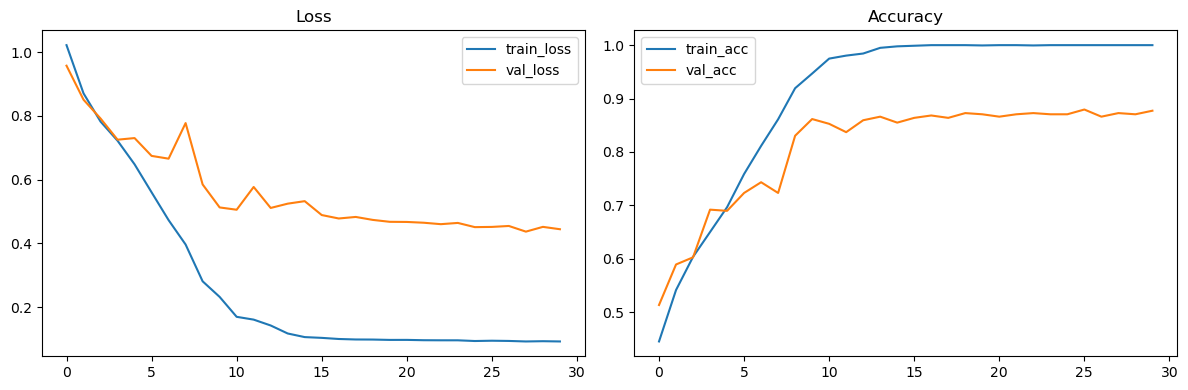

In [10]:
# ----------------------------
# Plot training curves
# ----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.show()


## Notes
- 本 notebook 已去掉原始工程中的批量重命名逻辑。
- 输入数据直接来自递归扫描的 `.nii` / `.nii.gz`。
- 如果显存不足，可降低 `TARGET_SHAPE`（如 `96,96,96`）和 `BATCH_SIZE`。
- 当前版本已从二分类改为三分类：CN / LMCI / AD。
- LMCI 被定义为 CN 和 AD 之间的中间阶段。
- 当前版本使用 3-view lightweight CapsuleNet classifier，复用了同一套 MRI 预处理、可视化和评估流程。
